# 분자 최적화 — 탐욕 알고리즘

**목표**: QED는 높고 logP는 낮은 분자 찾기

- QED (Quantitative Estimate of Drug-likeness): 약물다움. 0~1, 높을수록 좋음
- logP: 친지질성. 낮을수록 물에 잘 녹음 (약물 후보로 유리)

탐욕 알고리즘 전략: 현재 분자의 이웃 중 score가 가장 높은 분자로 이동한다. 더 나은 이웃이 없으면 멈춘다.

## 1. 준비

In [2]:
from rdkit import Chem, RDLogger
from rdkit.Chem import QED, Crippen

RDLogger.DisableLog('rdApp.*')    # 유효하지 않은 중간 구조에 대한 경고 끄기

## 2. 점수 함수

`score = QED - 0.5 × logP`

- QED가 클수록, logP가 작을수록 score가 커진다
- 가중치 0.5는 두 지표의 중요도 조절 — 실험으로 바꿔볼 값

In [3]:
def score(smi):
    mol = Chem.MolFromSmiles(smi)
    return QED.qed(mol) - 0.5 * Crippen.MolLogP(mol)

## 3. 이웃 분자 생성

분자의 원자 하나를 C, N, O 중 다른 것으로 **치환**한 이웃들을 만든다.

- 원자 번호만 바뀐다 — 원자 개수와 결합 구조는 그대로
- 유효하지 않은 분자(SanitizeMol 실패)는 자동으로 제외

In [1]:
def neighbors(smi):
    mol = Chem.MolFromSmiles(smi)
    result = []
    for i in range(mol.GetNumAtoms()):
        for atom_num in [6, 7, 8]:          # C, N, O
            rw = Chem.RWMol(mol)
            rw.GetAtomWithIdx(i).SetAtomicNum(atom_num)
            try:
                Chem.SanitizeMol(rw)
                result.append(Chem.MolToSmiles(rw))
            except:
                pass
    return result

## 4. 탐욕 루프

시작 분자: 이부프로펜 (진통제). QED는 괜찮지만 logP가 높다.

In [5]:
current = 'CC(C)Cc1ccc(cc1)C(C)C(=O)O'    # 이부프로펜
print('시작', current, round(score(current), 2))

for step in range(10):
    best = max(neighbors(current), key=score)
    if score(best) <= score(current):
        print('수렴')
        break
    current = best
    print(step + 1, current, round(score(current), 2))

시작 CC(C)Cc1ccc(cc1)C(C)C(=O)O -0.72
1 CC(N)Cc1ccc(C(C)C(=O)O)cc1 -0.09
2 CC(N)Cc1ccc(C(N)C(=O)O)cc1 0.35
3 NC(N)Cc1ccc(C(N)C(=O)O)cc1 0.72
4 NC(N)Cc1ccc(C(N)C(=O)O)cn1 0.99
5 NC(=O)C(N)c1ccc(CC(N)N)nc1 1.26
6 NC(=O)C(N)c1ccc(CC(N)N)nn1 1.54
7 NC(=O)C(N)c1ncc(CC(N)N)nn1 1.82
8 NC(=O)C(N)c1nnc(CC(N)N)nn1 2.1
9 NC(=O)C(N)c1nnc(OC(N)N)nn1 2.2
10 NC(=O)C(N)c1nnc(ON(N)N)nn1 2.24


## 5. 결과 확인

QED : 0.29
logP: -3.91


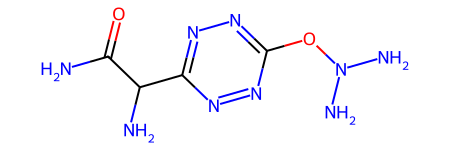

In [6]:
mol = Chem.MolFromSmiles(current)
print('QED :', round(QED.qed(mol), 2))
print('logP:', round(Crippen.MolLogP(mol), 2))
mol

## 실험 과제

1. **시작 분자 바꾸기** — 카페인(`CN1C=NC2=C1C(=O)N(C(=O)N2C)C`), 아스피린(`CC(=O)OC1=CC=CC=C1C(=O)O`) 등으로 시도해보자. 결과가 어떻게 달라지는가?
2. **가중치 바꾸기** — `score` 함수의 0.5를 0.1, 1.0, 2.0으로 바꿔보자. QED와 logP 중 어느 쪽이 더 많이 개선되는가?
3. **수렴 관찰** — 몇 단계에서 수렴하는가? 왜 그 이상 개선되지 않는가? (힌트: 이웃 생성 방식 check. 아래 함수로 다시 생성해보기.)

In [ ]:
def neighbors_with_add(smi):
    mol = Chem.MolFromSmiles(smi)
    result = list(neighbors(smi))    # 기존 치환 결과 포함
    
    # 각 원자에 C/N/O 하나씩 붙여보기
    for i in range(mol.GetNumAtoms()):
        for atom_num in [6, 7, 8]:
            rw = Chem.RWMol(mol)
            new_idx = rw.AddAtom(Chem.Atom(atom_num))
            rw.AddBond(i, new_idx, Chem.BondType.SINGLE)
            try:
                Chem.SanitizeMol(rw)
                result.append(Chem.MolToSmiles(rw))
            except:
                pass
    return result